In [1]:
import xgboost as xgb
from Tester import Tester
import numpy as np
import pickle
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess
from sklearn.model_selection import train_test_split

In [2]:
with open('test_lite.pkl', 'rb') as file:
    test=pickle.load(file)
with open('train_lite.pkl', 'rb') as file:
    train=pickle.load(file)
    

In [3]:
np.random.seed(42)
prices = [item.price for item in train]
documents = [item.test_prompt() for item in train]
processed_docs = [simple_preprocess(doc) for doc in documents]
w2v_model = Word2Vec(sentences=processed_docs,vector_size=400,window=5,min_count=1,workers=8)
def doc_vector(doc):
    doc_words = simple_preprocess(doc)
    word_vector = [w2v_model.wv[word] for word in doc_words if word in w2v_model.wv]
    return np.mean(word_vector,axis=0) if word_vector else np.zeros(w2v_model.vector_size)
x_w2v = np.array([doc_vector(doc) for doc in documents])

In [4]:
X_train_sub, X_val, y_train_sub, y_val = train_test_split(x_w2v, prices, test_size=0.15, random_state=42)

In [5]:
xgb_advanced_model = xgb.XGBRegressor(
    n_estimators=1000,
    max_depth=5,
    learning_rate = 0.05,
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
    objective="reg:squarederror"
)

In [6]:
xgb_advanced_model.fit(
    X_train_sub,
    y_train_sub,
    eval_set=[(X_val, y_val)], # The data to monitor for improvement
    verbose=False              # Set to True to see the performance at each round
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=-1, num_parallel_tree=None, ...)

In [17]:
print(f"Best iteration found: {xgb_advanced_model.best_iteration}")


Best iteration found: 997


In [18]:
def xgb_pricer(item):
    doc = item.test_prompt()
    x_t = doc_vector(doc)
    return max(0,xgb_advanced_model.predict([x_t])[0])

1: Guess: $3.87 Truth: $9.99 Error: $6.12 SLE: 0.66 Item: COCIDE 50 Pack Gas Burner Liners Aluminu...
2: Guess: $12.24 Truth: $18.79 Error: $6.55 SLE: 0.16 Item: Aluminum Range Hood Filter with Light Le...
3: Guess: $96.58 Truth: $169.99 Error: $73.41 SLE: 0.31 Item: TOREAD Portable Small Washing Machine, 1...
4: Guess: $12.01 Truth: $11.85 Error: $0.16 SLE: 0.00 Item: 4400EL2001A Clothes Dryer Belt Replaceme...
5: Guess: $136.87 Truth: $195.97 Error: $59.10 SLE: 0.13 Item: GE WR55X10956 Genuine OEM Main Control B...
6: Guess: $352.19 Truth: $539.99 Error: $187.80 SLE: 0.18 Item: 24'' Single Wall Oven, GASLAND Chef ES60...
7: Guess: $62.53 Truth: $139.94 Error: $77.41 SLE: 0.63 Item: Stainless Steel Stove Top Cover for Gas ...
8: Guess: $32.54 Truth: $12.99 Error: $19.55 SLE: 0.76 Item: Waterdrop Plus ADQ747935 MDJ64844601 Ref...
9: Guess: $63.60 Truth: $9.99 Error: $53.61 SLE: 3.14 Item: SAFELON 1 Pcs Baby Safety Fridge Lock, C...
10: Guess: $79.87 Truth: $9.90 Error: $69.97 SLE: 4.02

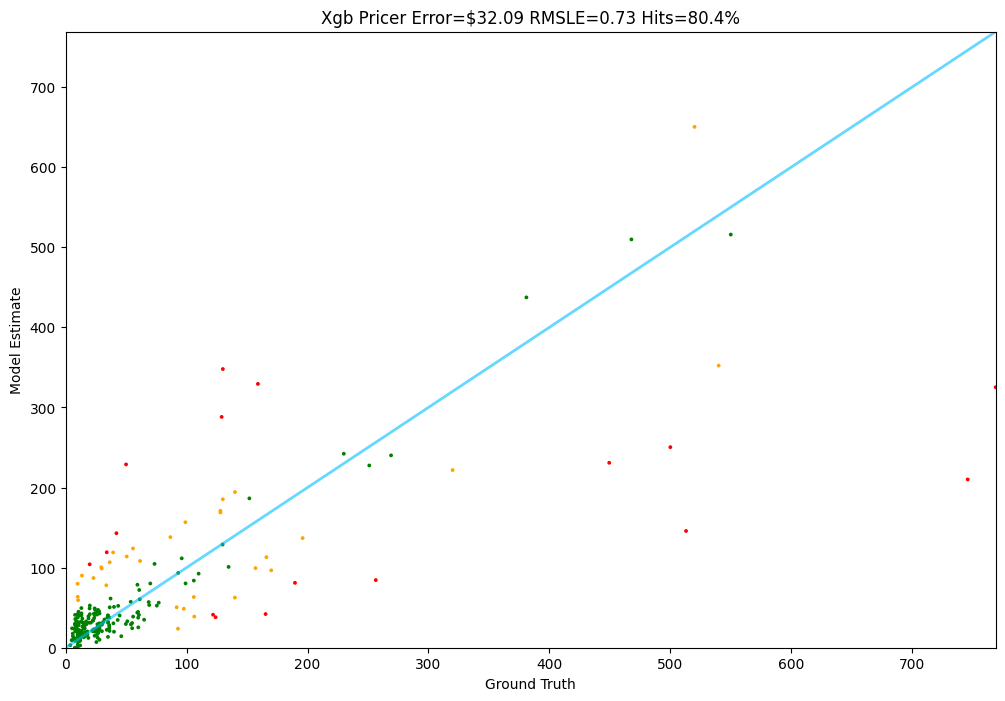

In [19]:
Tester.test(xgb_pricer,test)